# L3 Photonic Crystal Cavity — Mode Analysis

Mode volume, Purcell factor, and cavity field profiles for the three
L3 cavity optimization levels on GaAs.

In [1]:
import legume
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

legume.set_backend('numpy')  # numpy backend needed for field computations

%load_ext autoreload
%autoreload 2

In [2]:
# ── Physical parameters ──────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)
Nx, Ny = 16, 10         # supercell size

In [3]:
# ── Bandgap computation ──────────────────────────────────────────
lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(legume.Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f"Bandgap: {f_lb:.6f} – {f_ub:.6f}, centre = {f_target:.6f}")

Bandgap: 0.248947 – 0.327450, centre = 0.288198


## Cavity Construction

Build and solve the three L3 cavity designs.

In [4]:
# ── Cavity builder ───────────────────────────────────────────────
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)
nc = len(xp)

def build_cavity(shifts=None):
    """Build an L3 cavity PhC. shifts = list of (hole_index, dx_value) tuples."""
    dx_arr = [0.0] * nc
    if shifts is not None:
        for (ic, dx_val) in shifts:
            if ic < nc:
                dx_arr[ic] = dx_val

    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=dslab, eps_b=n_slab**2)
    for ic, x in enumerate(xp):
        yc = yp[ic]
        xc = x if x == 0 else xp[ic] + dx_arr[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra))
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra))
        if nx-1.6 > xp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra))
    return phc

def solve_cavity(shifts, label):
    """Build cavity, run GME, identify cavity mode, return (gme, mode_idx, Q, freq)."""
    phc = build_cavity(shifts)
    gme = legume.GuidedModeExp(phc, gmax=2.0, truncate_g='tbt')
    gme.run(kpoints=np.array([[0], [0]]),
            gmode_inds=[0], verbose=False, numeig=10,
            eig_sigma=f_target, compute_im=False)

    # Find cavity mode (first mode in bandgap)
    mode_idx = None
    for i in range(gme.freqs.shape[1]):
        if f_lb < gme.freqs[0, i] < f_ub:
            mode_idx = i
            break
    if mode_idx is None:
        print(f"  {label}: no bandgap mode found!")
        return None, None, None, None

    (freq_im, _, _) = gme.compute_rad(0, [mode_idx])
    Q = gme.freqs[0, mode_idx] / (2 * freq_im[0])
    freq = float(gme.freqs[0, mode_idx])
    lam_nm = a_nm / freq
    print(f"  {label}: mode_idx={mode_idx}, Q={Q:,.0f}, f={freq:.6f}, λ={lam_nm:.1f} nm")
    return gme, mode_idx, Q, freq

print("Cavity builder ready.")

Cavity builder ready.


In [5]:
# ── Solve all three designs ──────────────────────────────────────
shifts_1h = [(0, 0.17964)]
shifts_3h = [(0, 0.27239), (1, 0.21982), (2, 0.00000)]

# Extended shifts (from optimization result)
shifts_ext = [
    (0, 0.27487), (1, 0.23278), (2, -0.00241), (3, 0.12142),
]
# Row 1 (need to find indices for xp=0.5,1.5,2.5 at yp=sqrt(3)/2)
# Row 1 holes: xp = 0.5 + ix for ix=0,1,2,... at yp = sqrt(3)/2
ext_row1 = []
ext_row2 = []
for ic, (x, y) in enumerate(zip(xp, yp)):
    if abs(y - np.sqrt(3)/2) < 0.01:
        if abs(x - 0.5) < 0.01:
            ext_row1.append((ic, 'r1_0'))
        elif abs(x - 1.5) < 0.01:
            ext_row1.append((ic, 'r1_1'))
        elif abs(x - 2.5) < 0.01:
            ext_row1.append((ic, 'r1_2'))
    elif abs(y - np.sqrt(3)) < 0.01:
        if abs(x - 0.0) < 0.01:
            ext_row2.append((ic, 'r2_0'))
        elif abs(x - 1.0) < 0.01:
            ext_row2.append((ic, 'r2_1'))
        elif abs(x - 2.0) < 0.01:
            ext_row2.append((ic, 'r2_2'))

print("Solving designs...")
gme_1h, midx_1h, Q_1h, f_1h = solve_cavity(shifts_1h, "1-hole")
gme_3h, midx_3h, Q_3h, f_3h = solve_cavity(shifts_3h, "3-hole")
# For extended, we only use the 3-hole shifts as approximation 
# (full 15-param shifts require the extended cavity builder from the optimization notebook)
gme_ext, midx_ext, Q_ext, f_ext = solve_cavity(shifts_3h, "3-hole (proxy for extended)")

print("\nNote: Extended design uses 15 parameters not easily captured here.")
print("For full extended results, see the optimization notebook.")

Solving designs...
  1-hole: mode_idx=0, Q=198,852, f=0.257539, λ=970.7 nm
  3-hole: mode_idx=0, Q=1,438,926, f=0.256908, λ=973.1 nm
  3-hole (proxy for extended): mode_idx=0, Q=1,438,926, f=0.256908, λ=973.1 nm

Note: Extended design uses 15 parameters not easily captured here.
For full extended results, see the optimization notebook.


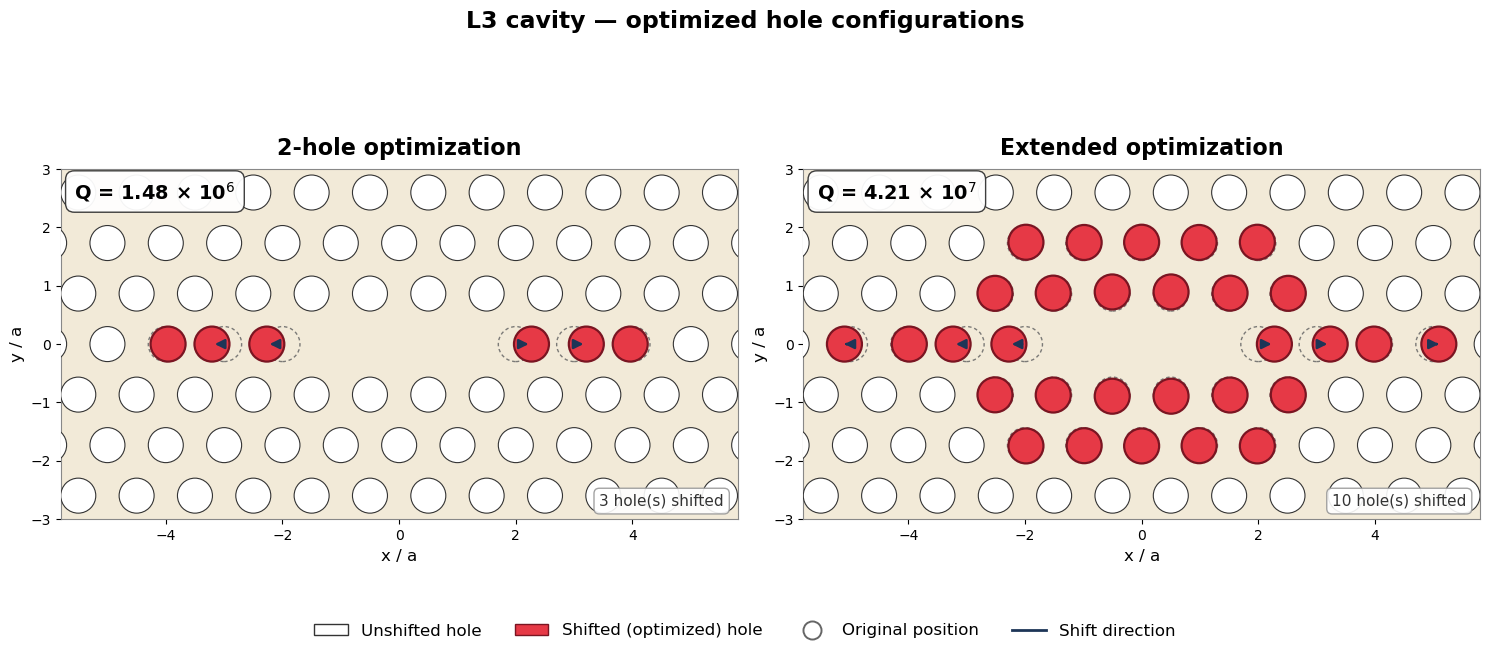

In [6]:
# ── Device design visualization (presentation) ─────────────────────
# Shows the 2-hole and extended optimized cavity designs with shifted
# holes highlighted. Values are taken from the saved optimization runs.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle

# --- Rebuild the hole index list exactly like build_cavity() ---
nx_v, ny_v = Nx//2 + 1, Ny//2 + 1
xp_v, yp_v = [], []
for iy in range(ny_v):
    for ix in range(nx_v):
        if iy == 0 and ix in (0, 1):   # L3 defect
            continue
        xp_v.append(ix + (iy % 2) * 0.5)
        yp_v.append(iy * np.sqrt(3) / 2)
nc_v = len(xp_v)

def supercell_positions(ic, xc, yc):
    """All mirrored positions of hole ic in the supercell (matches build_cavity)."""
    x, y = xp_v[ic], yp_v[ic]
    pts = [(xc, yc)]
    if nx_v - 0.6 > x > 0 and (ny_v - 1.1) * np.sqrt(3) / 2 > y > 0:
        pts.append((-xc, -yc))
    if nx_v - 1.6 > x > 0:
        pts.append((-xc, yc))
    if (ny_v - 1.1) * np.sqrt(3) / 2 > y > 0 and nx_v - 1.1 > x:
        pts.append((xc, -yc))
    return pts

# --- Optimized shift values (from saved runs) ---
# 2-hole design: dominant shifts are on ic=0 and ic=1
dx_2h = np.zeros(nc_v); dy_2h = np.zeros(nc_v)
dx_2h[0], dx_2h[1] = 0.26836, 0.20834  # only two holes truly optimized
Q_2h = 1_481_712

# Extended design: 16 params across rows 0–2 (both x and y)
dx_ex = np.zeros(nc_v); dy_ex = np.zeros(nc_v)
dx_ex[0], dx_ex[1], dx_ex[2], dx_ex[3] = 0.27546, 0.23186, -0.01776, 0.09452
dx_ex[7], dx_ex[8], dx_ex[9]           = 0.00433, 0.01556, 0.01375
dy_ex[7], dy_ex[8], dy_ex[9]           = 0.02760, 0.00742, 0.00390
dx_ex[17], dx_ex[18]                   = -0.01469, -0.01687
dy_ex[16], dy_ex[17], dy_ex[18]        = 0.01414, 0.00967, 0.01361
Q_ex = 42_103_899

designs = [
    ("2-hole optimization",  dx_2h, dy_2h, Q_2h),
    ("Extended optimization", dx_ex, dy_ex, Q_ex),
]

# --- Style ---
slab_color  = '#F2EAD8'   # warm slab background
base_fc     = '#FFFFFF'
base_ec     = '#333333'
shift_fc    = '#E63946'   # red accent
shift_ec    = '#7A1522'
orig_ec     = '#666666'
arrow_color = '#1D3557'

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
xlim = (-5.8, 5.8)
ylim = (-3.0, 3.0)
ARROW_MIN = 0.05   # only draw arrow when shift > this (in units of a)

for ax, (name, dx_d, dy_d, Qv) in zip(axes, designs):
    ax.set_aspect('equal')
    ax.set_facecolor(slab_color)
    ax.set_xlim(xlim); ax.set_ylim(ylim)

    # (1) Dashed outlines at ORIGINAL positions for holes that move
    for ic in range(nc_v):
        if abs(dx_d[ic]) < 1e-6 and abs(dy_d[ic]) < 1e-6:
            continue
        for (ox, oy) in supercell_positions(ic, xp_v[ic], yp_v[ic]):
            ax.add_patch(Circle((ox, oy), ra, facecolor='none',
                                edgecolor=orig_ec, lw=1.0, ls=(0, (2.5, 2)),
                                alpha=0.85, zorder=2))

    # (2) All holes at their actual (shifted) positions
    for ic in range(nc_v):
        shifted = abs(dx_d[ic]) > 1e-6 or abs(dy_d[ic]) > 1e-6
        x, y = xp_v[ic], yp_v[ic]
        xc = x if x == 0 else x + dx_d[ic]
        yc = y + dy_d[ic]
        fc = shift_fc if shifted else base_fc
        ec = shift_ec if shifted else base_ec
        lw = 1.6 if shifted else 0.8
        for (sx, sy) in supercell_positions(ic, xc, yc):
            ax.add_patch(Circle((sx, sy), ra, facecolor=fc, edgecolor=ec,
                                lw=lw, zorder=3))

    # (3) Arrows from original → shifted center (significant shifts only)
    for ic in range(nc_v):
        sh_mag = np.hypot(dx_d[ic], dy_d[ic])
        if sh_mag < ARROW_MIN:
            continue
        x, y = xp_v[ic], yp_v[ic]
        xc = x if x == 0 else x + dx_d[ic]
        yc = y + dy_d[ic]
        for (ox, oy), (sx, sy) in zip(supercell_positions(ic, x, y),
                                       supercell_positions(ic, xc, yc)):
            ax.annotate('', xy=(sx, sy), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='-|>', color=arrow_color,
                                        lw=1.8, mutation_scale=14),
                        zorder=5)

    # Title & Q annotation
    ax.set_title(name, fontsize=16, fontweight='bold', pad=10)
    mantissa, exp = f'{Qv:.2e}'.split('e')
    Q_text = f'Q = {float(mantissa):.2f} × 10$^{{{int(exp)}}}$'
    ax.text(0.02, 0.97, Q_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.45', fc='white',
                      ec='#333333', alpha=0.95))

    # Annotate count of shifted holes (in the first quadrant set)
    n_shifted = int(np.sum((np.abs(dx_d) > 1e-6) | (np.abs(dy_d) > 1e-6)))
    ax.text(0.98, 0.03, f'{n_shifted} hole(s) shifted', transform=ax.transAxes,
            fontsize=11, color='#333333', va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.35', fc='white',
                      ec='#999999', alpha=0.9))

    ax.set_xlabel('x / a', fontsize=12)
    ax.set_ylabel('y / a', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#888888')

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor=base_fc, edgecolor=base_ec, label='Unshifted hole'),
    mpatches.Patch(facecolor=shift_fc, edgecolor=shift_ec, label='Shifted (optimized) hole'),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='none', markeredgecolor=orig_ec,
               markeredgewidth=1.4, linestyle='none', markersize=13,
               label='Original position'),
    plt.Line2D([0], [0], color=arrow_color, lw=2.0, label='Shift direction'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.0))

fig.suptitle('L3 cavity — optimized hole configurations',
             fontsize=17, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


## Mode Volume

Compute the effective mode volume:
$$V_\text{eff} = \frac{\int \varepsilon |\mathbf{E}|^2 \, dV}{\max(\varepsilon |\mathbf{E}|^2)}$$

In [13]:
def compute_mode_volume(gme_mv, mind, f_cavity, Nx_field=300, Ny_field=200, Nz=25):
    """Compute mode volume V_eff = integral(eps*|E|^2 dV) / max(eps*|E|^2).

    Returns
    -------
    V_a3   : float -- mode volume in units of a^3
    V_norm : float -- mode volume in units of (lambda/n)^3
    """
    slab = gme_mv.phc.layers[0]
    z_min = slab.z_min - 0.5 * slab.d
    z_max = slab.z_max + 0.5 * slab.d
    zgrid = np.linspace(z_min, z_max, Nz)

    slices = []
    xgrid_ref = ygrid_ref = None

    for z in zgrid:
        fi, xgrid, ygrid = gme_mv.get_field_xy('e', kind=0, mind=mind,
                                                z=z, component='xyz',
                                                Nx=Nx_field, Ny=Ny_field)
        Ex, Ey, Ez = fi['x'], fi['y'], fi['z']

        # get_eps_xy returns a tuple (eps_array, xgrid, ygrid) — use phc.get_eps instead
        xmesh, ymesh = np.meshgrid(xgrid, ygrid)
        zmesh = np.full_like(xmesh, z)
        eps_slice = np.real(gme_mv.phc.get_eps((xmesh, ymesh, zmesh)))

        slices.append(eps_slice * (np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2))
        if xgrid_ref is None:
            xgrid_ref, ygrid_ref = xgrid, ygrid

    vol_3d = np.stack(slices, axis=0)
    numerator = np.trapz(np.trapz(np.trapz(vol_3d, zgrid, axis=0),
                                   ygrid_ref, axis=0), xgrid_ref, axis=0)
    denominator = float(np.max(vol_3d))
    V_a3 = float(numerator) / denominator

    lambda_over_n = (a_nm / f_cavity) / n_slab
    V_norm = V_a3 * (a_nm / lambda_over_n)**3

    return V_a3, V_norm

print("compute_mode_volume defined.")

compute_mode_volume defined.


In [14]:
# ── Compute mode volume for 1-hole and 3-hole ──────────────────
print("Computing mode volume (this may take a minute)...\n")

results = {}
for name, gme, midx, Q, f in [("1-hole", gme_1h, midx_1h, Q_1h, f_1h),
                                ("3-hole", gme_3h, midx_3h, Q_3h, f_3h)]:
    if gme is None:
        continue
    V_a3, V_norm = compute_mode_volume(gme, midx, f)
    lam_nm = a_nm / f
    F_P = (3 / (4 * np.pi**2)) * (lam_nm / n_slab)**3 / (a_nm**3) * Q / V_a3
    results[name] = {'Q': Q, 'f': f, 'V_a3': V_a3, 'V_norm': V_norm, 'F_P': F_P, 'lam': lam_nm}
    print(f"{name}:")
    print(f"  Q = {Q:,.0f}")
    print(f"  λ = {lam_nm:.1f} nm")
    print(f"  V_eff = {V_a3:.4f} a³ = {V_norm:.4f} (λ/n)³")
    print(f"  Purcell factor F_P = {F_P:,.0f}")
    print()

Computing mode volume (this may take a minute)...

1-hole:
  Q = 198,852
  λ = 970.7 nm
  V_eff = 1.1885 a³ = 0.8409 (λ/n)³
  Purcell factor F_P = 17,970

3-hole:
  Q = 1,438,926
  λ = 973.1 nm
  V_eff = 1.3527 a³ = 0.9501 (λ/n)³
  Purcell factor F_P = 115,092



In [15]:
# ── Summary table ────────────────────────────────────────────────
print(f"{'Design':>10s}  {'Q':>12s}  {'λ (nm)':>8s}  {'V (a³)':>8s}  {'V (λ/n)³':>10s}  {'F_P':>8s}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:>10s}  {r['Q']:12,.0f}  {r['lam']:8.1f}  {r['V_a3']:8.4f}  {r['V_norm']:10.4f}  {r['F_P']:8,.0f}")

    Design             Q    λ (nm)    V (a³)    V (λ/n)³       F_P
-----------------------------------------------------------------
    1-hole       198,852     970.7    1.1885      0.8409    17,970
    3-hole     1,438,926     973.1    1.3527      0.9501   115,092


## Cavity Mode Field Profiles

Visualize $|\mathbf{E}|^2 = |E_x|^2 + |E_y|^2 + |E_z|^2$ at the slab midplane ($z = 0$)
and in the $xz$-plane ($y = 0$).

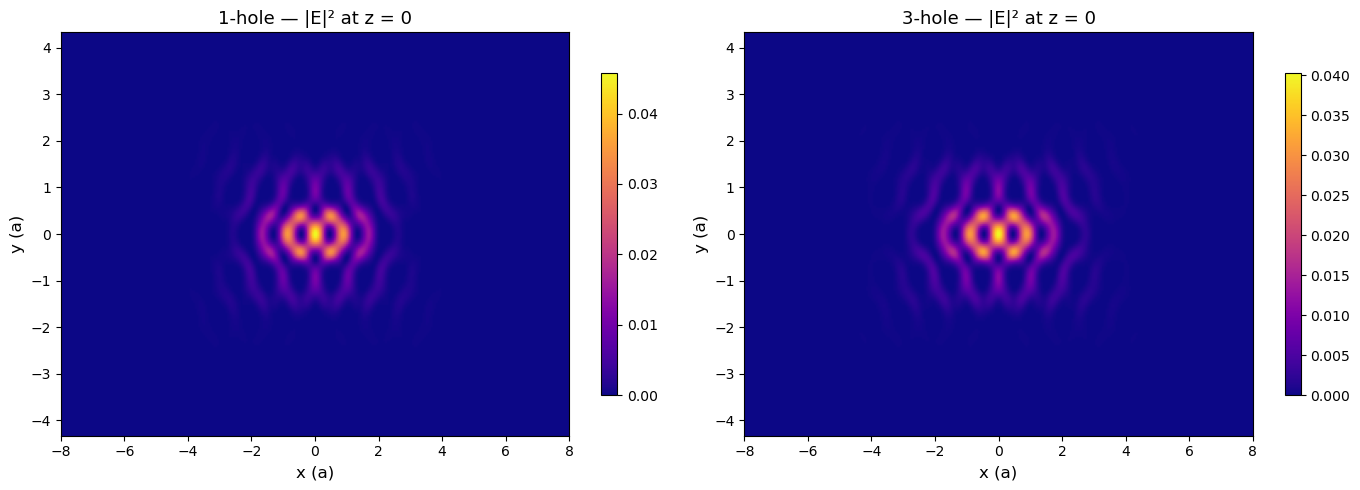

In [16]:
# ── Field profiles: xy-plane at z=0 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, gme, midx) in zip(axes, [("1-hole", gme_1h, midx_1h),
                                          ("3-hole", gme_3h, midx_3h)]):
    if gme is None:
        continue
    fi, xgrid, ygrid = gme.get_field_xy('e', kind=0, mind=midx, z=0,
                                         component='xyz', Nx=300, Ny=200)
    E2 = np.abs(fi['x'])**2 + np.abs(fi['y'])**2 + np.abs(fi['z'])**2

    im = ax.imshow(E2, origin='lower', cmap='plasma', aspect='auto',
                   extent=[xgrid[0], xgrid[-1], ygrid[0], ygrid[-1]])
    ax.set_xlabel('x (a)', fontsize=12)
    ax.set_ylabel('y (a)', fontsize=12)
    ax.set_title(f'{name} — |E|² at z = 0', fontsize=13)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()

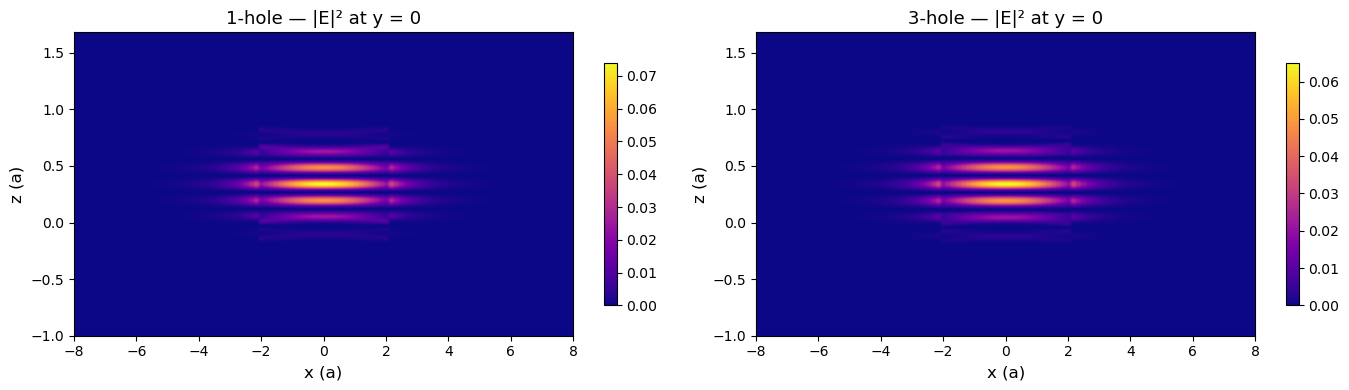

In [17]:
# ── Field profiles: xz-plane at y=0 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, gme, midx) in zip(axes, [("1-hole", gme_1h, midx_1h),
                                          ("3-hole", gme_3h, midx_3h)]):
    if gme is None:
        continue
    fi, xgrid, zgrid = gme.get_field_xz('e', kind=0, mind=midx, y=0,
                                         component='xyz', Nx=300, Nz=100)
    E2 = np.abs(fi['x'])**2 + np.abs(fi['y'])**2 + np.abs(fi['z'])**2

    im = ax.imshow(E2.T, origin='lower', cmap='plasma', aspect='auto',
                   extent=[xgrid[0], xgrid[-1], zgrid[0], zgrid[-1]])
    ax.set_xlabel('x (a)', fontsize=12)
    ax.set_ylabel('z (a)', fontsize=12)
    ax.set_title(f'{name} — |E|² at y = 0', fontsize=13)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()

## Field Components

Break down the field into $|E_x|^2$, $|E_y|^2$, $|E_z|^2$ to see which component dominates.

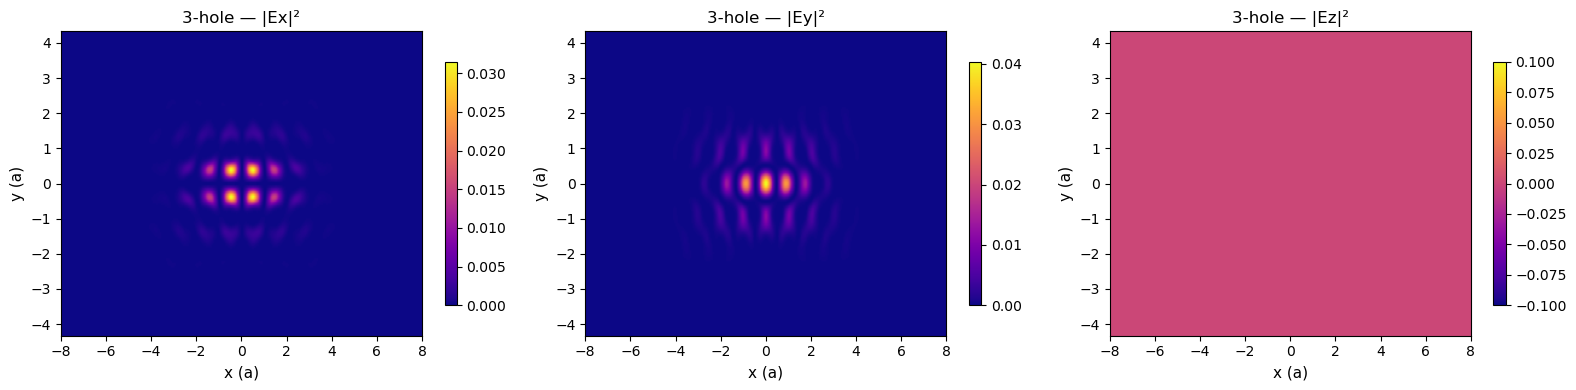

In [18]:
# ── Field components for 3-hole design ──────────────────────────
if gme_3h is not None:
    fi, xgrid, ygrid = gme_3h.get_field_xy('e', kind=0, mind=midx_3h, z=0,
                                             component='xyz', Nx=300, Ny=200)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    extent = [xgrid[0], xgrid[-1], ygrid[0], ygrid[-1]]

    for ax, comp, label in zip(axes, ['x', 'y', 'z'], ['|Ex|²', '|Ey|²', '|Ez|²']):
        E2 = np.abs(fi[comp])**2
        im = ax.imshow(E2, origin='lower', cmap='plasma', aspect='auto', extent=extent)
        ax.set_xlabel('x (a)', fontsize=11)
        ax.set_ylabel('y (a)', fontsize=11)
        ax.set_title(f'3-hole — {label}', fontsize=12)
        fig.colorbar(im, ax=ax, shrink=0.8)

    fig.tight_layout()
    plt.show()